# Sprint 3: SOTA Upgrade (Memory Efficient Pipeline)

Notebook ini mengimplementasikan perbaikan besar-besaran (Sprint 3) untuk menyamakan performa dengan project SOTA MSCNN-BiLSTM-AE.

## Key Improvements:
1. **Preprocessing Baru:** MinMax Scaler (0-1) yang bersih, fit hanya pada Benign Train.
2. **Clipping:** Menangani outlier ekstrim di data Test dengan clipping ke [0, 1].
3. **Memory Efficient:** Menggunakan `tf.data.Dataset` generator untuk streaming data (anti-OOM).
4. **Modular:** Menggunakan script terpisah untuk preprocessing yang konsisten.

In [14]:
# @title Colab Bootstrap (with Drive Persistence)
# Jalankan cell ini jika di Google Colab untuk setup environment
from pathlib import Path
import os
import subprocess
import sys
import shutil

COLAB_BOOTSTRAP_ENABLE = True
COLAB_REPO_URL = "https://github.com/akwancakra/nids-cnn-lstm-autoencoder.git"
COLAB_BRANCH = "feat/sprint3-sota-upgrade"
COLAB_REPO_DIR = Path("/content/nids-cnn-lstm-autoencoder")

# Drive Persistence Config
COLAB_DRIVE_MOUNT = Path("/content/drive")
COLAB_PROJECT_DRIVE_ROOT = COLAB_DRIVE_MOUNT / "MyDrive/nids-cnn-lstm-autoencoder"

def _is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _run_shell(cmd: list[str], cwd: Path | None = None) -> None:
    print(f"[CMD] {' '.join(cmd)}")
    subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=True)

def _ensure_symlink_dir(repo_path: Path, drive_target: Path) -> None:
    """Symlink repo folder to drive folder for persistence."""
    drive_target.mkdir(parents=True, exist_ok=True)

    if repo_path.is_symlink():
        if repo_path.resolve() == drive_target.resolve():
            print(f"[INFO] Symlink OK: {repo_path} -> {drive_target}")
            return
        repo_path.unlink()
    elif repo_path.exists():
        if any(repo_path.iterdir()):
            print(f"[WARN] Folder exists and not empty: {repo_path}. Skipping link.")
            return
        repo_path.rmdir()

    repo_path.parent.mkdir(parents=True, exist_ok=True)
    os.symlink(str(drive_target), str(repo_path), target_is_directory=True)
    print(f"[INFO] Symlink created: {repo_path} -> {drive_target}")

if _is_colab_runtime() and COLAB_BOOTSTRAP_ENABLE:
    from google.colab import drive
    drive.mount(str(COLAB_DRIVE_MOUNT))

    if not COLAB_REPO_DIR.exists():
        _run_shell(["git", "clone", "-b", COLAB_BRANCH, COLAB_REPO_URL, str(COLAB_REPO_DIR)])
    else:
        _run_shell(["git", "fetch", "--all"], cwd=COLAB_REPO_DIR)
        _run_shell(["git", "checkout", COLAB_BRANCH], cwd=COLAB_REPO_DIR)
        _run_shell(["git", "pull", "origin", COLAB_BRANCH], cwd=COLAB_REPO_DIR)

    # PERSISTENCE: Link Sprint 3 Data & Models to Drive
    # 1. Processed Data
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "data/research/sprint3_upgrade/processed",
        COLAB_PROJECT_DRIVE_ROOT / "data/research/sprint3_upgrade/processed"
    )
    # 2. Models & Results
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "research/sprint3_upgrade/models",
        COLAB_PROJECT_DRIVE_ROOT / "research/sprint3_upgrade/models"
    )
    _ensure_symlink_dir(
        COLAB_REPO_DIR / "research/sprint3_upgrade/results",
        COLAB_PROJECT_DRIVE_ROOT / "research/sprint3_upgrade/results"
    )

    # Set Working Directory
    os.chdir(COLAB_REPO_DIR)
    print(f"[INFO] Working Directory set to: {os.getcwd()}")
else:
    print("Not in Colab or Bootstrap disabled.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[CMD] git fetch --all
[CMD] git checkout feat/sprint3-sota-upgrade
[CMD] git pull origin feat/sprint3-sota-upgrade
[INFO] Symlink OK: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed
[INFO] Symlink OK: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/models -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/models
[INFO] Symlink OK: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results -> /content/drive/MyDrive/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results
[INFO] Working Directory set to: /content/nids-cnn-lstm-autoencoder


In [10]:
# Setup Project Root & Imports
import os
import sys
from pathlib import Path
import yaml
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import glob
from tqdm.notebook import tqdm

# Deteksi Project Root (Fallback mechanism)
try:
    # Jika di Colab dan sudah chdir, getcwd() adalah root
    PROJECT_ROOT = Path(os.getcwd()).resolve()

    # Validasi sederhana: cek folder research ada atau tidak
    if not (PROJECT_ROOT / "research").exists():
        # Coba naik satu level (jika notebook dijalankan lokal dari folder notebooks/)
        if (PROJECT_ROOT.parent / "research").exists():
            PROJECT_ROOT = PROJECT_ROOT.parent
        else:
            # Fallback hardcoded untuk Colab jika chdir gagal
            PROJECT_ROOT = Path("/content/nids-cnn-lstm-autoencoder")
except Exception:
    PROJECT_ROOT = Path(".")

print(f"Project Root: {PROJECT_ROOT}")
sys.path.append(str(PROJECT_ROOT))

# Load Config Sprint 3
config_path = PROJECT_ROOT / "research/sprint3_upgrade/config/experiment_v1.yaml"

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Experiment: {config['experiment_name']}")
    print(f"Config Loaded: {config_path}")
else:
    print(f"ERROR: Config not found at {config_path}")
    print("Make sure you have cloned the repo and switched to the correct branch.")

Project Root: /content/nids-cnn-lstm-autoencoder
Experiment: sprint3_sota_upgrade_v1
Config Loaded: /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/config/experiment_v1.yaml


### 1.1 EDA Data Raw (Opsional)
Inspeksi singkat file CSV mentah untuk melihat kolom, missing values, dan distribusi label.

In [17]:
import pandas as pd
from pathlib import Path
import glob
import os
from IPython.display import display

def pick_first_existing(paths):
    for p in paths:
        if p is None:
            continue
        p = Path(p)
        if p.exists():
            return p
    return None

raw_train_dir = None
raw_test_dir = None

if 'raw_train' in locals() and 'raw_test' in locals():
    raw_train_dir = Path(raw_train)
    raw_test_dir = Path(raw_test)

if raw_train_dir is None and 'config' in locals() and 'paths' in config:
    if 'raw_train' in config['paths']:
        raw_train_dir = PROJECT_ROOT / config['paths']['raw_train']
    if 'raw_test' in config['paths']:
        raw_test_dir = PROJECT_ROOT / config['paths']['raw_test']

if raw_train_dir is None:
    raw_train_dir = pick_first_existing([
        "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017",
        PROJECT_ROOT / "data" / "raw" / "CIC-IDS2017"
    ])
if raw_test_dir is None:
    raw_test_dir = pick_first_existing([
        "/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018",
        PROJECT_ROOT / "data" / "raw" / "CSE-CIC-IDS2018"
    ])

def inspect_raw_dir(raw_dir, name):
    print(f"\n--- RAW {name} ---")
    if raw_dir is None or not Path(raw_dir).exists():
        print("Raw folder not found.")
        return
    raw_dir = Path(raw_dir)
    files = sorted(glob.glob(str(raw_dir / "*.csv")))
    if not files:
        files = sorted(glob.glob(str(raw_dir / "**" / "*.csv"), recursive=True))
    if not files:
        print(f"No CSV files found at {raw_dir}")
        return
    print(f"Folder: {raw_dir}")
    print(f"Files: {len(files)}")
    sample_file = files[0]
    print(f"Sample file: {os.path.basename(sample_file)}")
    try:
        df = pd.read_csv(sample_file, nrows=20000)
    except Exception:
        df = pd.read_csv(sample_file, nrows=5000, engine="python")
    print(f"Shape: {df.shape}")
    display(df.head(5))
    print("Missing (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    label_col = "Label" if "Label" in df.columns else ("label" if "label" in df.columns else None)
    if label_col:
        print(f"Label distribution ({label_col}):")
        print(df[label_col].value_counts().head(20))

inspect_raw_dir(raw_train_dir, "CIC-IDS2017 (Train)")
inspect_raw_dir(raw_test_dir, "CSE-CIC-IDS2018 (Test)")



--- RAW CIC-IDS2017 (Train) ---
Folder: /content/drive/MyDrive/nids-data/raw/CIC-IDS2017
Files: 8
Sample file: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Shape: (20000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Missing (top 10):
Flow Bytes/s                    3
 Flow Duration                  0
 Destination Port               0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Total Fwd Packets              0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Std          0
dtype: int64

--- RAW CSE-CIC-IDS2018 (Test) ---
Folder: /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018
Files: 3
Sample file: 02-14-2018.csv
Shape: (20000, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0,0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0,0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0,0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0,0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0,0,0,0,0.0,0.000000,0,0,Benign


Missing (top 10):
Dst Port           0
Protocol           0
Timestamp          0
Flow Duration      0
Tot Fwd Pkts       0
Tot Bwd Pkts       0
TotLen Fwd Pkts    0
TotLen Bwd Pkts    0
Fwd Pkt Len Max    0
Fwd Pkt Len Min    0
dtype: int64
Label distribution (Label):
Label
FTP-BruteForce    19902
Benign               98
Name: count, dtype: int64


### 1.2 Ringkasan Label CIC vs CSE (Raw)
Menampilkan total benign/attack dan distribusi per serangan dari dataset mentah.

In [18]:
import pandas as pd
from pathlib import Path
import glob
from IPython.display import display

def find_label_column(sample_file):
    cols = pd.read_csv(sample_file, nrows=0, low_memory=False).columns.tolist()
    clean_map = {str(c).strip().lower(): c for c in cols}
    return clean_map.get("label")

def count_labels_in_dir(raw_dir, dataset_name, chunksize=200000):
    print(f"\n--- LABEL SUMMARY {dataset_name} ---")
    if raw_dir is None or not Path(raw_dir).exists():
        print("Raw folder not found.")
        return None, None
    raw_dir = Path(raw_dir)
    files = sorted(glob.glob(str(raw_dir / "*.csv")))
    if not files:
        files = sorted(glob.glob(str(raw_dir / "**" / "*.csv"), recursive=True))
    if not files:
        print(f"No CSV files found at {raw_dir}")
        return None, None
    label_col = find_label_column(files[0])
    if not label_col:
        print("Label column not found.")
        return None, None
    counts = {}
    for f in files:
        for chunk in pd.read_csv(f, usecols=[label_col], chunksize=chunksize, low_memory=False):
            vc = chunk[label_col].fillna("UNKNOWN").astype(str).value_counts()
            for k, v in vc.items():
                counts[k] = counts.get(k, 0) + int(v)
    if not counts:
        print("No label counts found.")
        return None, None
    total = int(sum(counts.values()))
    benign_total = int(sum(v for k, v in counts.items() if str(k).strip().upper() == "BENIGN"))
    attack_total = int(total - benign_total)
    overall_df = pd.DataFrame([
        {"dataset": dataset_name, "benign": benign_total, "attack": attack_total, "total": total}
    ])
    attack_rows = [
        {"dataset": dataset_name, "label": k, "count": int(v)}
        for k, v in counts.items()
        if str(k).strip().upper() != "BENIGN"
    ]
    attack_df = (
        pd.DataFrame(attack_rows).sort_values(by="count", ascending=False)
        if attack_rows
        else pd.DataFrame(columns=["dataset", "label", "count"])
    )
    display(overall_df)
    display(attack_df)
    return overall_df, attack_df

count_labels_in_dir(raw_train_dir, "CIC-IDS2017 (Train)")
count_labels_in_dir(raw_test_dir, "CSE-CIC-IDS2018 (Test)")



--- LABEL SUMMARY CIC-IDS2017 (Train) ---


,dataset,benign,attack,total
0,CIC-IDS2017 (Train),2273097,557646,2830743


,dataset,label,count
9,CIC-IDS2017 (Train),DoS Hulk,231073
1,CIC-IDS2017 (Train),PortScan,158930
0,CIC-IDS2017 (Train),DDoS,128027
12,CIC-IDS2017 (Train),DoS GoldenEye,10293
7,CIC-IDS2017 (Train),FTP-Patator,7938
8,CIC-IDS2017 (Train),SSH-Patator,5897
10,CIC-IDS2017 (Train),DoS slowloris,5796
11,CIC-IDS2017 (Train),DoS Slowhttptest,5499
2,CIC-IDS2017 (Train),Bot,1966
4,CIC-IDS2017 (Train),Web Attack � Brute Force,1507



--- LABEL SUMMARY CSE-CIC-IDS2018 (Test) ---


,dataset,benign,attack,total
0,CSE-CIC-IDS2018 (Test),2110475,1035250,3145725


,dataset,label,count
5,CSE-CIC-IDS2018 (Test),DoS attacks-Hulk,461912
0,CSE-CIC-IDS2018 (Test),FTP-BruteForce,193360
1,CSE-CIC-IDS2018 (Test),SSH-Bruteforce,187589
4,CSE-CIC-IDS2018 (Test),DoS attacks-SlowHTTPTest,139890
2,CSE-CIC-IDS2018 (Test),DoS attacks-GoldenEye,41508
3,CSE-CIC-IDS2018 (Test),DoS attacks-Slowloris,10990
6,CSE-CIC-IDS2018 (Test),Label,1


(                  dataset   benign   attack    total
 0  CSE-CIC-IDS2018 (Test)  2110475  1035250  3145725,
                   dataset                     label   count
 5  CSE-CIC-IDS2018 (Test)          DoS attacks-Hulk  461912
 0  CSE-CIC-IDS2018 (Test)            FTP-BruteForce  193360
 1  CSE-CIC-IDS2018 (Test)            SSH-Bruteforce  187589
 4  CSE-CIC-IDS2018 (Test)  DoS attacks-SlowHTTPTest  139890
 2  CSE-CIC-IDS2018 (Test)     DoS attacks-GoldenEye   41508
 3  CSE-CIC-IDS2018 (Test)     DoS attacks-Slowloris   10990
 6  CSE-CIC-IDS2018 (Test)                     Label       1)

## 1. Data Inspection (EDA)
Menganalisis distribusi data mentah (RAW) atau processed yang tersedia.
Cell ini akan mencoba mendeteksi data secara otomatis di path standar.

[INFO] Inspecting data at: /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed

--- Analyzing Train Set (Benign Expected) ---
Sample File: train_shard_0.npz
Keys: ['X', 'y']
  X: shape=(97677, 10, 77), dtype=float64
  y: shape=(97677,), dtype=float64
Scanning 4 files (sample) for label distribution...


Scanning Train Set (Benign Expected):   0%|          | 0/4 [00:00<?, ?it/s]

Scanned Samples: 943378
Estimated Total Samples: 943378
Label Distribution (Scanned): {np.float64(0.0): 943378}


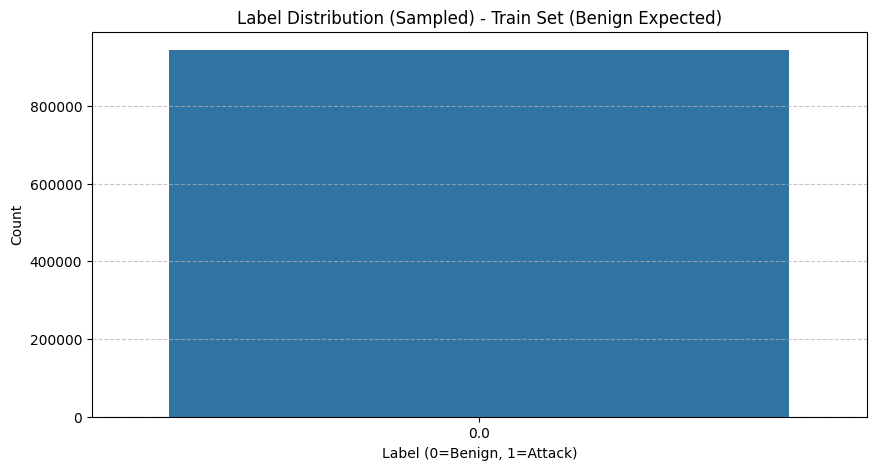


--- Analyzing Test Set (Mixed Expected) ---
Sample File: test_shard_0.npz
Keys: ['X', 'y']
  X: shape=(1044742, 10, 77), dtype=float64
  y: shape=(1044742,), dtype=int64
Scanning 2 files (sample) for label distribution...


Scanning Test Set (Mixed Expected):   0%|          | 0/2 [00:00<?, ?it/s]

Scanned Samples: 2085281
Estimated Total Samples: 2085281
Label Distribution (Scanned): {np.int64(0): 1648228, np.int64(1): 437053}


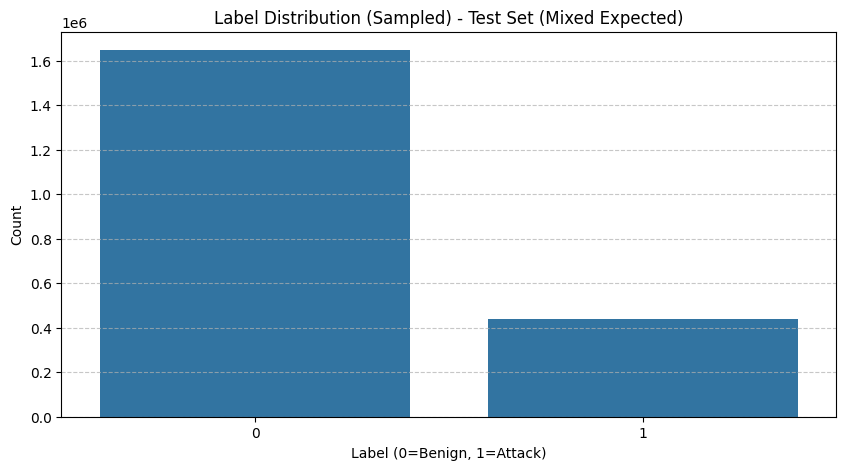

In [19]:
# @title Data Inspection & Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
import numpy as np
import os
import glob
from pathlib import Path

# Default values to prevent NameError
train_files = []
test_files = []

# --- AUTO DETECT DATA PATHS ---
# Coba deteksi path data processed (hasil run sebelumnya)
try:
    base_processed = None
    if 'config' in locals() and 'paths' in config:
        if 'processed_data' in config['paths']:
            base_processed = PROJECT_ROOT / config['paths']['processed_data']
        elif 'train_data' in config['paths']:
            base_processed = Path(config['paths']['train_data']).parent

    if base_processed is None:
        candidates = [
            Path("data/processed"),
            Path("../data/processed"),
            Path("/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed"),
            Path("/content/nids-mscnn-bilstm-autoencoder/data/processed")
        ]
        for p in candidates:
            if p.exists():
                base_processed = p
                break

    if base_processed:
        print(f"[INFO] Inspecting data at: {base_processed}")
        train_files = sorted(glob.glob(str(base_processed / "train" / "*.npz")))
        test_files = sorted(glob.glob(str(base_processed / "test" / "*.npz")))

        if not train_files:
             train_files = sorted(glob.glob(str(base_processed / "**" / "train" / "*.npz"), recursive=True))
        if not test_files:
             test_files = sorted(glob.glob(str(base_processed / "**" / "test" / "*.npz"), recursive=True))
    else:
        print("[WARN] Processed data directory not found yet. Run preprocessing first or check paths.")

except Exception as e:
    print(f"[ERROR] Path detection failed: {e}")

def analyze_distribution(files, set_name="Dataset"):
    print(f"\n--- Analyzing {set_name} ---")
    if not files:
        print("No files found.")
        return

    try:
        with np.load(files[0], allow_pickle=True) as data:
            print(f"Sample File: {os.path.basename(files[0])}")
            print(f"Keys: {list(data.keys())}")
            for k in data.keys():
                obj = data[k]
                print(f"  {k}: shape={obj.shape}, dtype={obj.dtype}")
    except Exception as e:
        print(f"Error reading sample file: {e}")
        return

    label_counts = Counter()
    total_samples = 0

    scan_limit = min(len(files), 100)
    print(f"Scanning {scan_limit} files (sample) for label distribution...")

    for f in tqdm(files[:scan_limit], desc=f"Scanning {set_name}"):
        try:
            with np.load(f, allow_pickle=True) as data:
                y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                if y is not None:
                    if len(y.shape) > 0:
                        label_counts.update(y)
                    else:
                        label_counts[y.item()] += 1
                    total_samples += len(y) if len(y.shape) > 0 else 1
        except: pass

    scale_factor = len(files) / scan_limit
    estimated_total = int(total_samples * scale_factor)

    print(f"Scanned Samples: {total_samples}")
    print(f"Estimated Total Samples: {estimated_total}")
    print(f"Label Distribution (Scanned): {dict(label_counts)}")

    if label_counts:
        plt.figure(figsize=(10, 5))
        keys = list(label_counts.keys())
        vals = list(label_counts.values())
        sns.barplot(x=keys, y=vals)
        plt.title(f"Label Distribution (Sampled) - {set_name}")
        plt.xlabel("Label (0=Benign, 1=Attack)")
        plt.ylabel("Count")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

if train_files:
    analyze_distribution(train_files, "Train Set (Benign Expected)")
else:
    print("Train files not found. (Maybe preprocessing hasn't run yet?)")

if test_files:
    analyze_distribution(test_files, "Test Set (Mixed Expected)")
else:
    print("Test files not found.")


## 1.3 Feature Drift Analysis (Domain Adaptation)
Menganalisis pergeseran distribusi fitur antara CIC-IDS2017 (Source) dan CSE-CIC-IDS2018 (Target).
Fitur dengan drift tinggi (KS Statistic > 0.5) akan didrop untuk meningkatkan generalisasi.

In [11]:
# Run Drift Analysis
import os
from pathlib import Path

output_dir = PROJECT_ROOT / "research/sprint3_upgrade/results"
script_path = PROJECT_ROOT / "research/sprint3_upgrade/scripts/analyze_drift.py"

# Define Raw Paths (Logic copied from Preprocessing cell)
if os.path.exists("/content/drive/MyDrive/nids-data/raw"):
    raw_train = Path("/content/drive/MyDrive/nids-data/raw/CIC-IDS2017")
    raw_test = Path("/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018")
else:
    raw_train = PROJECT_ROOT / config['paths']['raw_train']
    raw_test = PROJECT_ROOT / config['paths']['raw_test']

print(f"Raw Train: {raw_train}")
print(f"Raw Test: {raw_test}")

if raw_train.exists() and raw_test.exists():
    cmd = f'python "{script_path}" --raw_train "{raw_train}" --raw_test "{raw_test}" --output_dir "{output_dir}" --ks_threshold 0.5'
    print(f"Executing: {cmd}")
    !{cmd}
else:
    print("Raw data not found, skipping drift analysis.")


Raw Train: /content/drive/MyDrive/nids-data/raw/CIC-IDS2017
Raw Test: /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018
Executing: python "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/scripts/analyze_drift.py" --raw_train "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017" --raw_test "/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018" --output_dir "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results" --ks_threshold 0.5
Loading Source Data (2017)...
Loading /content/drive/MyDrive/nids-data/raw/CIC-IDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading /content/drive/MyDrive/nids-data/raw/CIC-IDS2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading /content/drive/MyDrive/nids-data/raw/CIC-IDS2017/Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Target Data (2018)...
Loading /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018/02-14-2018.csv...
Loading /content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018/02-15-2018.csv...

## 2. Preprocessing (SOTA Style with Domain Adaptation)
Jalankan script preprocessing baru yang menerapkan MinMax(0-1), Clipping, dan **Drop High Drift Features**.

In [15]:
# Run Preprocessing Script (If data not exists)
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
train_dir = processed_dir / "train"
test_dir = processed_dir / "test"

# FORCE RE-RUN PREPROCESSING TO FIX LABEL BUG
RUN_PREPROCESSING = True # Set to True because we are dropping features (Drift Analysis), so we MUST regenerate data.

# --- AUTO DETECT & REUSE LOGIC ---
# Check if processed data already exists (locally or via symlink)
if train_dir.exists() and any(train_dir.iterdir()):
    print("[INFO] Processed data found! But RUN_PREPROCESSING is set to True to apply Drift Analysis changes.")
    # RUN_PREPROCESSING = False # Disabled to force re-run

# Adjust Raw Paths for Colab Support
if os.path.exists("/content/drive/MyDrive/nids-data/raw"):
    print("[INFO] Colab Drive Raw Data Detected.")
    raw_train = Path("/content/drive/MyDrive/nids-data/raw/CIC-IDS2017")
    raw_test = Path("/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018")
else:
    # Local fallback or repo path
    raw_train = PROJECT_ROOT / config['paths']['raw_train']
    raw_test = PROJECT_ROOT / config['paths']['raw_test']
# -------------------------------------------------

if RUN_PREPROCESSING:
    print("Running Preprocessing Script... (This may take a while)")
    script_path = PROJECT_ROOT / "research/sprint3_upgrade/scripts/preprocess_sota.py"

    # Check raw data
    if not raw_train.exists():
        print(f"Error: Raw train path {raw_train} not found!")
        print("Please check config or mount drive correctly.")
    else:
        # Check for drop list
        drop_list_path = PROJECT_ROOT / "research/sprint3_upgrade/results/high_drift_features.txt"
        drop_arg = ""
        if drop_list_path.exists():
            print(f"Found drop list at {drop_list_path}")
            drop_arg = f'--drop_features "{drop_list_path}"'

        cmd = f'python "{script_path}" --raw_train "{raw_train}" --raw_test "{raw_test}" --output_dir "{processed_dir}" --seq_len {config["preprocessing"]["sequence_length"]} --stride {config["preprocessing"]["stride"]} {drop_arg}'
        print(f"Executing: {cmd}")
        !{cmd}
else:
    print("Skipping Preprocessing (Data already exists).")
    print(f"Data Location: {processed_dir}")

[INFO] Colab Drive Raw Data Detected.
Running Preprocessing Script... (This may take a while)
Found drop list at /content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results/high_drift_features.txt
Executing: python "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/scripts/preprocess_sota.py" --raw_train "/content/drive/MyDrive/nids-data/raw/CIC-IDS2017" --raw_test "/content/drive/MyDrive/nids-data/raw/CSE-CIC-IDS2018" --output_dir "/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed" --seq_len 10 --stride 1 --drop_features "/content/nids-cnn-lstm-autoencoder/research/sprint3_upgrade/results/high_drift_features.txt"
Dropping 0 features: []
Found 8 training files.
Found 3 test files.
Computing global statistics for scaling...
Fitting Scaler: 100% 8/8 [00:30<00:00,  3.77s/it]
Scaler saved to /content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/scaler.pkl
Processing Train Data:  50% 4/8 [01:13<01:13, 18.45s/it]
Traceback (most

In [16]:
# @title Verify New Test Set Distribution
import numpy as np
import glob
import os

test_files = sorted(glob.glob(str(test_dir / "*.npz")))
if test_files:
    print(f"Found {len(test_files)} test files. Checking the first one...")
    sample_file = test_files[0]
    with np.load(sample_file, allow_pickle=True) as data:
        y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
        if y is not None:
            unique, counts = np.unique(y, return_counts=True)
            dist = dict(zip(unique, counts))
            print(f"Label Distribution in {os.path.basename(sample_file)}: {dist}")
            if 0 in dist and 1 in dist:
                print("✅ SUCCESS: Both Benign (0) and Attack (1) are present!")
            else:
                print("❌ ERROR: Missing classes. Check preprocessing logic.")
else:
    print("No test files found. Preprocessing might have failed.")

No test files found. Preprocessing might have failed.


## 3. Data Pipeline (Memory Efficient)
Menggunakan `tf.data.Dataset` generator agar hemat RAM.

In [ ]:
# @title 1. Data Pipeline (Flexible: Memory Efficient vs Speed Optimized)
# Pilih mode sesuai kapasitas RAM Colab Anda.

# --- KONFIGURASI MODE ---
PIPELINE_MODE = "SPEED_OPTIMIZED"  # Options: "MEMORY_EFFICIENT" (12GB RAM) or "SPEED_OPTIMIZED" (25GB+ RAM)
# -----------------------

import tensorflow as tf
import glob
import numpy as np
import os

print(f"[INFO] Pipeline Mode: {PIPELINE_MODE}")

def npz_generator(files):
    """
    Generator yang membaca file .npz dari list file satu per satu dan yield batch data.
    """
    if not files:
        # print(f"Warning: No files provided") # Silent warning to avoid spam in logs
        return

    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                # Handle keys
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)

                if X is None:
                    continue

                # Yield per sample (tf.data will batch it later)
                for i in range(len(X)):
                    # Autoencoder: Input = Target (X, X)
                    yield X[i], X[i] # Target is X for AE
        except Exception as e:
            print(f"Error reading {f}: {e}")

def create_dataset(files, batch_size=256, shuffle=True, input_shape=(10, 77)):
    """
    Membuat tf.data.Dataset dari list file shards.
    """
    # Tentukan output signature
    output_signature = (
        tf.TensorSpec(shape=input_shape, dtype=tf.float32), # Input X
        tf.TensorSpec(shape=input_shape, dtype=tf.float32)  # Target X (Autoencoder)
    )

    dataset = tf.data.Dataset.from_generator(
        lambda: npz_generator(files),
        output_signature=output_signature
    )

    # --- LOGIKA MODE ---
    if PIPELINE_MODE == "SPEED_OPTIMIZED":
        # Cache ke RAM setelah pembacaan pertama.
        # Epoch 1: Lambat (Read Disk + Cache). Epoch 2+: Cepat (Read RAM).
        # HATI-HATI: Butuh RAM besar (~20-30GB untuk full dataset)
        dataset = dataset.cache()
        shuffle_buffer = 50000 if shuffle else 1000
    else:
        # Memory Efficient (Streaming)
        # Tidak ada cache, baca disk terus menerus. Hemat RAM tapi lambat.
        shuffle_buffer = 10000 if shuffle else 1000

    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Helper untuk menghitung steps_per_epoch
def count_samples(files):
    total = 0
    if not files:
        print("Warning: No files to count.")
        return 0

    print(f"Counting samples from {len(files)} files...")
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                key = 'X' if 'X' in data else 'x'
                if key in data:
                    total += data[key].shape[0]
        except: pass
    return total

print("Data Pipeline Ready.")

## 4. Build & Train Model


In [ ]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Concatenate, Bidirectional, LSTM, Dropout, Flatten, Dense, RepeatVector, UpSampling1D
from tensorflow.keras.models import Model

# Setup Paths & Config
model_save_dir = PROJECT_ROOT / config['paths']['model_save_dir']
model_save_dir.mkdir(parents=True, exist_ok=True)
best_model_path = model_save_dir / "best_model.keras"
final_model_path = model_save_dir / "final_model.keras"

FORCE_RETRAIN = False # Set True to force retrain even if model exists

def build_model(input_shape, encoding_dim=16):
    inputs = Input(shape=input_shape)
    # Encoder
    # (10, 77)
    conv1 = Conv1D(32, 3, activation='relu', padding='same')(inputs)
    pool1 = MaxPooling1D(2, padding='same')(conv1) # (5, 32)
    conv2 = Conv1D(16, 3, activation='relu', padding='same')(pool1)
    # Skip pool2 agar tidak ganjil/sulit di upsample balik ke 10
    lstm1 = LSTM(64, return_sequences=True)(conv2) # (5, 64)
    dropout1 = Dropout(0.2)(lstm1)
    flatten = Flatten()(dropout1)
    encoded = Dense(encoding_dim, activation='relu')(flatten)

    # Decoder
    repeat = RepeatVector(5)(encoded) # (5, 16)
    lstm2 = LSTM(64, return_sequences=True)(repeat) # (5, 64)
    dropout2 = Dropout(0.2)(lstm2)
    conv3 = Conv1D(16, 3, activation='relu', padding='same')(dropout2) # (5, 16)
    upsample1 = UpSampling1D(2)(conv3) # (10, 16)
    decoded = Conv1D(input_shape[1], 3, activation='sigmoid', padding='same')(upsample1) # (10, 77)

    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

# --- LOGIC: LOAD OR TRAIN ---

if not FORCE_RETRAIN and (best_model_path.exists() or final_model_path.exists()):
    print("✅ Pre-trained model found! Loading model...")
    load_path = best_model_path if best_model_path.exists() else final_model_path

    try:
        model = tf.keras.models.load_model(str(load_path))
        print(f"Model loaded from: {load_path}")
        model.summary()

        # We STILL need Validation Data for threshold calculation later
        print("\n[INFO] Loading Validation Data for Threshold Calculation...")
        BATCH_SIZE = config['training']['batch_size']
        if 'train_dir' not in locals():
            train_dir = PROJECT_ROOT / config['paths']['processed_data'] / "train"

        all_files = sorted(glob.glob(str(train_dir / "*.npz")))
        # Use simple split for now just to get val data
        split_idx = int(len(all_files) * (1 - config['training']['validation_split']))
        val_files = all_files[split_idx:]

        if val_files:
            val_ds = create_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False)
            print(f"Validation Dataset Loaded ({len(val_files)} files). Ready for Thresholding.")
        else:
             print("Warning: No validation files found.")

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("Falling back to training...")
        FORCE_RETRAIN = True

if FORCE_RETRAIN or ('model' not in locals()):
    print("⚡ Starting Training Process...")

    BATCH_SIZE = config['training']['batch_size']

    # 1. Dataset Setup
    if 'train_dir' not in locals():
        train_dir = PROJECT_ROOT / config['paths']['processed_data'] / "train"

    all_files = sorted(glob.glob(str(train_dir / "*.npz")))
    # Limit number of files used for training if running in light mode
    # all_files = all_files[:10]

    split_idx = int(len(all_files) * (1 - config['training']['validation_split']))
    train_files = all_files[:split_idx]
    val_files = all_files[split_idx:]

    train_samples = count_samples(train_files)
    val_samples = count_samples(val_files)

    print(f"Total Train Samples: {train_samples}")
    print(f"Total Val Samples: {val_samples}")

    if train_samples > 0:
        # Create Datasets
        train_ds = create_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True).repeat()
        val_ds = create_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False)

        train_steps = max(1, train_samples // BATCH_SIZE)
        val_steps = max(1, val_samples // BATCH_SIZE)

        # Build Model
        input_shape = (10, 77)
        model = build_model(input_shape, encoding_dim=config['model']['encoding_dim'])
        model.summary()

        # Callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=config['training']['patience'], restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(str(best_model_path), save_best_only=True, monitor='val_loss')
        ]

        # Fit
        history = model.fit(
            train_ds,
            epochs=config['training']['epochs'],
            steps_per_epoch=train_steps,
            validation_data=val_ds,
            validation_steps=val_steps,
            callbacks=callbacks,
            verbose=1
        )

        model.save(str(final_model_path))
        print(f"Model saved to {final_model_path}")

        # Plot History
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Val')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.show()
    else:
        print("❌ No training data found. Cannot train.")

In [ ]:
# @title 4.1 Determine Threshold & Visualization (Auto-Load Test Sample)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import tensorflow as tf
from tqdm.notebook import tqdm
import os

# --- Helper to load sample test data if not exists ---
def get_visualization_test_ds(config, project_root):
    print("⚠️ 'cse_ds' not found. Loading small test sample for visualization...")
    try:
        # Locate Test Files
        test_dir = None
        possible_paths = [
            project_root / config['paths']['processed_data'] / "test",
            project_root / "data/processed/test",
            Path("/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test")
        ]
        for p in possible_paths:
            if p.exists() and list(p.glob("*.npz")):
                test_dir = p
                break

        if not test_dir:
            print("❌ Could not find Test Data path.")
            return None

        test_files = sorted(glob.glob(str(test_dir / "*.npz")))[:5] # Take only 5 files for speed
        print(f"   Loading sample from: {test_dir} ({len(test_files)} files)")

        # Generator for (X, y)
        def viz_gen():
            for f in test_files:
                try:
                    with np.load(f, allow_pickle=True) as data:
                        X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                        y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)
                        if X is not None and y is not None:
                            for i in range(len(X)):
                                yield X[i], y[i]
                except: pass

        output_signature = (
            tf.TensorSpec(shape=(10, 77), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
        ds = tf.data.Dataset.from_generator(viz_gen, output_signature=output_signature)
        return ds.batch(256).take(200) # Limit to 200 batches (~50k samples)

    except Exception as e:
        print(f"❌ Error loading test sample: {e}")
        return None

def find_threshold_and_visualize(model, val_ds, test_ds=None, percentile=95):
    print("Calculating reconstruction errors...")

    # 1. Calculate Benign Errors (Validation Set)
    val_errors = []
    print("  - Scanning Validation Set (Benign)...")
    val_batches = iter(val_ds)
    # Limit val scanning to avoid long wait if dataset is huge, or scan full if needed
    # Using full val_ds is safer for threshold
    for batch_x, _ in tqdm(val_ds, desc="Val Errors", leave=False):
        recon = model.predict(batch_x, verbose=0)
        mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
        val_errors.extend(mse)
    val_errors = np.array(val_errors)

    # 2. Calculate Test Errors (Mixed) for Viz
    test_errors = []
    test_labels = []

    if test_ds:
        print("  - Scanning Test Set Sample (Attack vs Benign)...")
        for batch_x, batch_y in tqdm(test_ds, desc="Test Errors", leave=False):
            recon = model.predict(batch_x, verbose=0)
            mse = np.mean(np.square(batch_x - recon), axis=(1, 2))
            test_errors.extend(mse)
            test_labels.extend(batch_y.numpy())

        test_errors = np.array(test_errors)
        test_labels = np.array(test_labels)

    # Determine Threshold
    threshold_val = np.percentile(val_errors, percentile)

    # Visualisasi
    plt.figure(figsize=(12, 6))

    # Plot Benign (Validation) - Reference
    sns.kdeplot(val_errors, color='blue', fill=True, label='Benign (Train/Val)', clip=(0, 0.1))

    # Plot Test (Attack vs Benign in Test)
    if len(test_errors) > 0:
        mask_attack = test_labels == 1
        mask_benign_test = test_labels == 0

        if np.any(mask_attack):
            sns.kdeplot(test_errors[mask_attack], color='red', fill=True, label='Attack (Test)', clip=(0, 0.1), alpha=0.3)
            # Add mean marker
            plt.axvline(np.mean(test_errors[mask_attack]), color='red', linestyle=':', alpha=0.5)

        if np.any(mask_benign_test):
            sns.kdeplot(test_errors[mask_benign_test], color='green', fill=True, label='Benign (Test)', clip=(0, 0.1), alpha=0.3)

    plt.axvline(threshold_val, color='black', linestyle='--', linewidth=2, label=f'Threshold {percentile}% ({threshold_val:.4f})')

    plt.title(f"Reconstruction Error Density (Threshold: {threshold_val:.5f})")
    plt.xlabel("Mean Squared Error (MSE)")
    plt.xlim(0, 0.1) # Fokus zoom di area krusial
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nConfiguration:")
    print(f"  percentile: {percentile}%")
    print(f"  threshold : {threshold_val:.6f}")

    return threshold_val

# Execute
if 'val_ds' in locals() and 'model' in locals():
    # 1. Prepare Visualization Dataset
    viz_ds = None
    if 'cse_ds' in locals():
        viz_ds = cse_ds.take(200) # Use existing if avail
    else:
        # Load ad-hoc
        viz_ds = get_visualization_test_ds(config, PROJECT_ROOT)

    # 2. Run
    # Gunakan 99% agar lebih ketat, tapi grafik akan menunjukkan apakah itu cukup
    threshold = find_threshold_and_visualize(model, val_ds, test_ds=viz_ds, percentile=99.0)
    print(f"✅ Threshold set to: {threshold}")
else:
    print("❌ Validation dataset (val_ds) or Model not found. Run training first.")

In [ ]:
# @title 4.2 Scientific Diagnosis: Feature Shift Analysis (Robust)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pandas as pd
from pathlib import Path

def load_data_sample(config, split_name, n_files=5):
    """
    Memuat sampel data secara manual dari disk untuk keperluan diagnosis.
    Menangani path Colab vs Local secara otomatis.
    """
    print(f"--- Loading {split_name} Sample ---")

    # 1. Cari Path
    data_dir = None
    if 'config' in locals():
        candidates = [
            PROJECT_ROOT / config['paths']['processed_data'] / split_name,
            PROJECT_ROOT / "data/processed" / split_name,
            Path(f"/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/{split_name}")
        ]
    else:
        # Fallback hardcoded
        candidates = [
            Path(f"data/processed/{split_name}"),
            Path(f"../data/processed/{split_name}")
        ]

    for p in candidates:
        if p.exists() and list(p.glob("*.npz")):
            data_dir = p
            break

    if not data_dir:
        print(f"❌ Could not find {split_name} data.")
        return None

    # 2. Load Data (X only)
    files = sorted(glob.glob(str(data_dir / "*.npz")))[:n_files]
    print(f"  Source: {data_dir}")
    print(f"  Files : {len(files)}")

    X_list = []
    y_list = []

    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                X_batch = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                y_batch = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)

                if X_batch is not None:
                    # Ambil label Benign (0) saja untuk perbandingan Apple-to-Apple
                    # Kita ingin melihat apakah Benign Train vs Benign Test berbeda jauh
                    if y_batch is not None:
                        benign_mask = (y_batch == 0)
                        if np.sum(benign_mask) > 0:
                            X_list.append(X_batch[benign_mask])
                    else:
                        # Jika tidak ada label, ambil semua (asumsi train bersih)
                        X_list.append(X_batch)
        except Exception as e:
            print(f"  Error reading {f}: {e}")

    if X_list:
        X_concat = np.concatenate(X_list, axis=0)
        print(f"  Loaded Shape: {X_concat.shape}")
        return X_concat
    else:
        return None

# --- MAIN DIAGNOSIS ---

# 1. Load Samples (Benign Train vs Benign Test)
print("Diagnosing Covariate Shift (Feature Distribution Mismatch)...")
train_sample = load_data_sample(config if 'config' in locals() else None, "train", n_files=5)
test_sample = load_data_sample(config if 'config' in locals() else None, "test", n_files=5) # CSE-CIC-IDS2018

if train_sample is not None and test_sample is not None:
    # 2. Calculate Statistics per Feature
    # Shape: (samples, time_steps, features) -> Average over samples & time steps
    # Kita ingin melihat statistik per FEATURE (channel 0-76)

    # Rata-rata fitur di seluruh timestep (mean aggregasi)
    train_mean = np.mean(train_sample, axis=(0, 1))
    test_mean = np.mean(test_sample, axis=(0, 1))

    train_min = np.min(train_sample, axis=(0, 1))
    test_min = np.min(test_sample, axis=(0, 1))

    train_max = np.max(train_sample, axis=(0, 1))
    test_max = np.max(test_sample, axis=(0, 1))

    # 3. Calculate Shift
    delta_mean = test_mean - train_mean
    abs_delta = np.abs(delta_mean)

    # 4. Visualization
    features = np.arange(len(train_mean))

    plt.figure(figsize=(15, 6))
    plt.bar(features, delta_mean, color=np.where(delta_mean > 0, 'red', 'blue'), alpha=0.7)
    plt.title("Feature Shift Analysis: Benign Test (2018) - Benign Train (2017)")
    plt.xlabel("Feature Index (0-76)")
    plt.ylabel("Mean Difference (Shift)")
    plt.grid(True, alpha=0.3)

    # Highlight Extreme Shifts
    threshold_shift = 0.1 # Fitur yang bergeser lebih dari 0.1 (mengingat skala 0-1)
    outliers = np.where(abs_delta > threshold_shift)[0]

    for idx in outliers:
        plt.annotate(f"{idx}", (idx, delta_mean[idx]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

    plt.show()

    # 5. Top Drifting Features Report
    print("\nTop 10 Feature Shifts (Significant Drift):")
    # Sort by absolute drift
    sorted_idx = np.argsort(abs_delta)[::-1]

    print(f"{'Feat Idx':<10} | {'Train Mean':<12} | {'Test Mean':<12} | {'Delta':<12} | {'Status'}")
    print("-" * 65)
    for i in range(min(20, len(features))):
        idx = sorted_idx[i]
        diff = delta_mean[idx]
        if abs(diff) > 0.05: # Hanya tampilkan yang signifikan
            status = "CRITICAL" if abs(diff) > 0.2 else "Warning"
            print(f"{idx:<10} | {train_mean[idx]:.4f}       | {test_mean[idx]:.4f}       | {diff:+.4f}      | {status}")

    # 6. Conclusion
    print("\nINTERPRETATION:")
    print("1. Jika Delta positif besar (Red Bars): Data Test nilainya jauh lebih besar dari Train.")
    print("   -> Autoencoder akan menganggap ini anomaly (MSE tinggi).")
    print("2. Jika ini terjadi pada data BENIGN 2018, itulah penyebab False Positive.")
    print("3. Solusi: Kita harus membuang fitur ini atau melakukan Scaling ulang (Domain Adaptation).")

else:
    print("❌ Cannot perform diagnosis. Missing data.")

## 5. Evaluation (Dual-Set)
Evaluasi model pada dua dataset:
1. **CSE-CIC-IDS2018 (Wajib):** Test set utama (Zero-Day Attack).
2. **CIC-IDS2017 (Opsional):** Test set in-domain (jika tersedia).

Set variable `RUN_ALL_EVAL = True` untuk menjalankan keduanya.

In [ ]:
# @title 5.1 Shared Evaluation Functions & Setup
# Jalankan cell ini DULU sebelum menjalankan evaluasi di bawah.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm
from pathlib import Path

# --- CONFIG: EVALUATION SPEED ---
EVAL_SAMPLE_FRACTION = 0.2  # 0.2 = Run on 20% of data (Faster). 1.0 = Full Data.
# --------------------------------

def evaluate_performance(y_true, y_pred, name="Test Set", color='Blues'):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n[{name}] Performance:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color)
    plt.title(f'Confusion Matrix ({name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    return f1

def npz_generator_with_label(files):
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as data:
                X = data['X'] if 'X' in data else (data['x'] if 'x' in data else None)
                y = data['y'] if 'y' in data else (data['Y'] if 'Y' in data else None)

                if X is not None and y is not None:
                    for i in range(len(X)):
                        yield X[i], y[i]
        except Exception: pass

def create_eval_dataset(files, batch_size=256):
    # Specialized dataset for evaluation returning (X, y) instead of (X, X)
    output_signature = (
        tf.TensorSpec(shape=(10, 77), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32) # Label is scalar int
    )

    dataset = tf.data.Dataset.from_generator(
        lambda: npz_generator_with_label(files),
        output_signature=output_signature
    )
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def calculate_errors_and_predict(dataset, model, threshold, steps=None):
    all_errors = []
    all_y_true = []

    desc = "Predicting"
    prog_bar = tqdm(dataset, total=steps, desc=desc) if steps else tqdm(dataset, desc=desc)

    # Counter untuk limit sample
    batch_count = 0

    for batch_x, batch_y in prog_bar:
        # Predict Reconstruction
        recon = model.predict(batch_x, verbose=0)
        # Calculate MSE per sample
        mse = np.mean(np.square(batch_x - recon), axis=(1, 2))

        all_errors.extend(mse)
        all_y_true.extend(batch_y.numpy())

        # Stop jika sudah mencapai steps (untuk fast mode)
        batch_count += 1
        if steps and batch_count >= steps:
            break

    all_errors = np.array(all_errors)
    all_y_true = np.array(all_y_true)

    # Thresholding
    y_pred = (all_errors > threshold).astype(int)

    return all_y_true, y_pred, all_errors

# Helper Count
def count_samples(files):
    total = 0
    if not files: return 0
    for f in files[:10]: # Check first 10 files to estimate avg
         try:
            with np.load(f, allow_pickle=True) as data:
                key = 'X' if 'X' in data else 'x'
                if key in data: total += data[key].shape[0]
         except: pass
    # Estimate total based on avg
    if len(files) > 10:
        avg = total / 10
        total = int(avg * len(files))
    else:
        # If fewer than 10, we already counted exact
        pass
    return total

print("✅ Evaluation functions ready.")

In [ ]:
# @title 5.2 EVALUATION: CSE-CIC-IDS2018 (Zero-Day / Cross-Domain)
print("="*40)
print("RUNNING: CSE-CIC-IDS2018 EVALUATION")
print("="*40)

if 'threshold' not in locals():
    print("⚠️ Threshold not defined. Using default 0.05")
    threshold = 0.05
else:
    print(f"Using Threshold: {threshold}")

# FORCE RELOAD CSE DATASET in (X, y) mode
cse_ds = None
cse_steps = None
test_files = []

# Locate files
# Prioritize config paths
if 'config' in locals():
    if 'test_data' in config['paths']:
        base_test = PROJECT_ROOT / config['paths']['test_data']
    elif 'processed_data' in config['paths']:
        base_test = PROJECT_ROOT / config['paths']['processed_data'] / "test"
    else:
        base_test = Path("data/processed/test")

    if base_test.exists():
        test_files = sorted(glob.glob(str(base_test / "*.npz")))

# Fallback Search if config didn't work
if not test_files:
    candidates = [
        PROJECT_ROOT / "data/processed/test",
        Path("/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed/test"),
        Path("/content/nids-mscnn-bilstm-autoencoder/data/processed/test")
    ]
    for c in candidates:
        if c.exists():
            test_files = sorted(glob.glob(str(c / "*.npz")))
            if test_files: break

if test_files:
    total_samples = count_samples(test_files)
    BATCH_SIZE = config['training']['batch_size'] if 'config' in locals() else 256

    full_steps = max(1, total_samples // BATCH_SIZE)
    # Apply Sample Fraction
    cse_steps = int(full_steps * EVAL_SAMPLE_FRACTION)
    cse_steps = max(1, cse_steps) # Minimal 1 step

    print(f"Found {len(test_files)} files. Est. Total Samples: {total_samples}")
    print(f"Running FAST EVALUATION on {EVAL_SAMPLE_FRACTION*100}% Data.")
    print(f"Processing {cse_steps} batches (approx {cse_steps*BATCH_SIZE} samples)...")

    # Create DATASET with LABELS specifically for evaluation
    cse_ds = create_eval_dataset(test_files, batch_size=BATCH_SIZE)

    y_true_cse, y_pred_cse, errors_cse = calculate_errors_and_predict(cse_ds, model, threshold, cse_steps)
    evaluate_performance(y_true_cse, y_pred_cse, name="CSE-CIC-IDS2018", color='Blues')
else:
    print("❌ CSE-CIC-IDS2018 Dataset files not found.")

In [ ]:
# @title 5.3 EVALUATION: CIC-IDS2017 (In-Domain Reference)
print("\n" + "="*40)
print("RUNNING: CIC-IDS2017 EVALUATION (In-Domain)")
print("="*40)

if 'threshold' not in locals():
    print("⚠️ Threshold not defined. Using default 0.05")
    threshold = 0.05

cic_test_path = None
possible_roots = [
    PROJECT_ROOT / "data" / "processed",
    Path("/content/nids-cnn-lstm-autoencoder/data/research/sprint3_upgrade/processed"),
    Path("/content/nids-mscnn-bilstm-autoencoder/data/processed")
]

for root in possible_roots:
    candidate = root / "test_cic"
    if candidate.exists():
        cic_test_path = candidate
        print(f"Found CIC Test Path at: {candidate}")
        break

if cic_test_path:
    cic_files = sorted(glob.glob(str(cic_test_path / "*.npz")))
    if cic_files:
        BATCH_SIZE = config['training']['batch_size'] if 'config' in locals() else 256
        total_samples_cic = count_samples(cic_files)
        full_steps_cic = max(1, total_samples_cic // BATCH_SIZE)

        # Apply Sample Fraction
        cic_steps = int(full_steps_cic * EVAL_SAMPLE_FRACTION)
        cic_steps = max(1, cic_steps)

        print(f"Running FAST EVALUATION on {EVAL_SAMPLE_FRACTION*100}% CIC Data.")
        print(f"Processing {cic_steps} batches (approx {cic_steps*BATCH_SIZE} samples)...")

        # Create Dataset
        cic_ds = create_eval_dataset(cic_files, batch_size=BATCH_SIZE)

        y_true_cic, y_pred_cic, errors_cic = calculate_errors_and_predict(cic_ds, model, threshold, cic_steps)
        evaluate_performance(y_true_cic, y_pred_cic, name="CIC-IDS2017", color='Greens')
    else:
        print("❌ CIC Test folder empty.")
else:
    print("ℹ️ CIC-IDS2017 Test Data folder 'test_cic' not found. (Ini wajar jika Anda hanya fokus pada Cross-Domain)")

## 6. Comprehensive Experiment Summary & Review
Ringkasan lengkap hasil eksperimen untuk evaluasi mandiri dan reviewer.
Mencakup metrik kunci, interpretasi performa, dan catatan anomali.

In [ ]:
# @title Performance Comparison (Visual Summary)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_performance_summary():
    data = []

    # Collect CSE Results
    if 'y_true_cse' in locals() and 'y_pred_cse' in locals():
        acc_cse = accuracy_score(y_true_cse, y_pred_cse)
        rec_cse = recall_score(y_true_cse, y_pred_cse, zero_division=0)
        prec_cse = precision_score(y_true_cse, y_pred_cse, zero_division=0)
        f1_cse = f1_score(y_true_cse, y_pred_cse, zero_division=0)
        data.extend([
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'Accuracy', 'Value': acc_cse},
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'Recall', 'Value': rec_cse},
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'Precision', 'Value': prec_cse},
            {'Dataset': 'CSE-CIC-IDS2018 (Zero-Day)', 'Metric': 'F1-Score', 'Value': f1_cse},
        ])

    # Collect CIC Results
    if 'y_true_cic' in locals() and 'y_pred_cic' in locals():
        acc_cic = accuracy_score(y_true_cic, y_pred_cic)
        rec_cic = recall_score(y_true_cic, y_pred_cic, zero_division=0)
        prec_cic = precision_score(y_true_cic, y_pred_cic, zero_division=0)
        f1_cic = f1_score(y_true_cic, y_pred_cic, zero_division=0)
        data.extend([
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'Accuracy', 'Value': acc_cic},
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'Recall', 'Value': rec_cic},
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'Precision', 'Value': prec_cic},
            {'Dataset': 'CIC-IDS2017 (In-Domain)', 'Metric': 'F1-Score', 'Value': f1_cic},
        ])

    if not data:
        print("No evaluation results found to plot.")
        return

    df_summary = pd.DataFrame(data)

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_summary, x='Metric', y='Value', hue='Dataset', palette='viridis')
    plt.title('Performance Comparison: Zero-Day vs In-Domain')
    plt.ylim(0, 1.1)
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Add values on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    plt.legend(loc='lower right')
    plt.show()

plot_performance_summary()